In [2]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.2 MB 13.0 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.2 MB 11.9 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.2 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 12.1 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 12.2 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   -

In [2]:
# Cargamos librerías

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Cargar archivos

FEATURES_DIR = Path(r"C:\Users\Celia\Documents\Master\2 Trimestre\TFM\miProyecto\features_resnet50")

X_train_features = np.load(FEATURES_DIR / "X_train_features.npy")
X_val_features = np.load(FEATURES_DIR / "X_val_features.npy")
X_test_features = np.load(FEATURES_DIR / "X_test_features.npy")

y_train_encoded = np.load(FEATURES_DIR / "y_train.npy")
y_val_encoded = np.load(FEATURES_DIR / "y_val.npy")
y_test_encoded = np.load(FEATURES_DIR / "y_test.npy")

classes = np.load(FEATURES_DIR / "classes.npy", allow_pickle=True)

print("Train:", X_train_features.shape, y_train_encoded.shape)
print("Val:", X_val_features.shape, y_val_encoded.shape)
print("Test:", X_test_features.shape, y_test_encoded.shape)
print("Clases:", classes)

Train: (2100, 2048) (2100,)
Val: (152, 2048) (152,)
Test: (148, 2048) (148,)
Clases: ['ala_fija' 'helicoptero' 'multirotor' 'no_uav']


In [4]:
# Función para AdaBoost
# Crea un clasificador AdaBoost con árboles de decisión poco profundos (max_depth=1).

SEED = 42

def crear_adaboost(n_estimators=100, learning_rate=0.5, random_state=42):

    base_tree = DecisionTreeClassifier(
        max_depth=1,
        random_state=random_state
    )

    model = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=n_estimators, 
        learning_rate=learning_rate, 
        random_state=random_state
    )

    return model

In [5]:
# Escenario semi-supervisado

LABELED_RATIO = 0.30  # 30 % etiquetado inicial

indices = np.arange(len(X_train_features))

idx_L, idx_U = train_test_split(
    indices,
    train_size=LABELED_RATIO,
    stratify=y_train_encoded,
    random_state=SEED
)

X_L = X_train_features[idx_L]
y_L = y_train_encoded[idx_L]

X_U = X_train_features[idx_U]

# Estas etiquetas reales de U NO se usan para entrenar.
# Solo sirven para comprobar después la calidad de las pseudo-etiquetas.
y_U_real = y_train_encoded[idx_U]

print("Conjunto etiquetado inicial L:", X_L.shape, y_L.shape)
print("Conjunto no etiquetado U:", X_U.shape, y_U_real.shape)

print("\nDistribución de clases en L:")
for i, class_name in enumerate(classes):
    print(class_name, ":", np.sum(y_L == i))

print("\nDistribución de clases en U:")
for i, class_name in enumerate(classes):
    print(class_name, ":", np.sum(y_U_real == i))

Conjunto etiquetado inicial L: (630, 2048) (630,)
Conjunto no etiquetado U: (1470, 2048) (1470,)

Distribución de clases en L:
ala_fija : 157
helicoptero : 158
multirotor : 157
no_uav : 158

Distribución de clases en U:
ala_fija : 368
helicoptero : 367
multirotor : 368
no_uav : 367


In [6]:
# Modelo base: AdaBoost solo supervisado con L 

baseline_model = crear_adaboost(
    n_estimators=100,
    learning_rate=0.5,
    random_state=SEED
)

baseline_model.fit(X_L, y_L)

y_val_pred_baseline = baseline_model.predict(X_val_features)
baseline_val_acc = accuracy_score(y_val_encoded, y_val_pred_baseline)

print("Accuracy en validación del AdaBoost supervisado con L:", baseline_val_acc)

Accuracy en validación del AdaBoost supervisado con L: 0.7171052631578947


## PRUEBA PRELIMINAR: AdaBoost semi-supervisado con umbral fijo de confianza

Se probó inicialmente un umbral absoluto THRESHOLD = 0.80 para aceptar pseudo-etiquetas. Sin embargo, las probabilidades generadas por AdaBoost estaban muy próximas entre sí y no se seleccionaban nuevas muestras. Por ello, se sustituyó esta estrategia por un criterio relativo basado en seleccionar el top 10% de muestras más confiables. 


In [7]:
# AdaBoost semi-supervisado con pseudo-etiquetado (no ejecutar)

#THRESHOLD = 0.80       # confianza mínima para aceptar pseudo-etiquetas
#MAX_ITERATIONS = 5     # número máximo de iteraciones

# Copias para ir ampliando el conjunto etiquetado
#X_labeled = X_L.copy()
#y_labeled = y_L.copy()

# Pesos: 1 para etiquetas reales
#sample_weights = np.ones(len(y_labeled))

# Copias del conjunto no etiquetado
#X_unlabeled = X_U.copy()
#y_unlabeled_real = y_U_real.copy()

#history = []

#for iteration in range(1, MAX_ITERATIONS + 1):

#    print(f"\nIteración {iteration}")

#    model = crear_adaboost(
#        n_estimators=100,
#        learning_rate=0.5,
#        random_state=SEED
#    )

#    model.fit(
#        X_labeled,
#        y_labeled,
#        sample_weight=sample_weights
#    )

    # Evaluación intermedia en validación
#    y_val_pred = model.predict(X_val_features)
#    val_acc = accuracy_score(y_val_encoded, y_val_pred)

#    print(f"Accuracy validación: {val_acc:.4f}")

#    if len(X_unlabeled) == 0:
#        print("No quedan imágenes no etiquetadas.")
#        break

    # Predicción de probabilidades sobre U
#    probabilities = model.predict_proba(X_unlabeled)

#    pseudo_labels = np.argmax(probabilities, axis=1)
#    confidences = np.max(probabilities, axis=1)

#    selected_mask = confidences >= THRESHOLD

#    n_selected = np.sum(selected_mask)
#    print(f"Pseudo-etiquetas aceptadas: {n_selected}")

#    if n_selected > 0:
#        pseudo_acc = accuracy_score(
#            y_unlabeled_real[selected_mask],
#            pseudo_labels[selected_mask]
#        )
#        print(f"Precisión de pseudo-etiquetas aceptadas: {pseudo_acc:.4f}")
#    else:
#        pseudo_acc = None

#    history.append({
#        "iteration": iteration,
#        "val_accuracy": val_acc,
#        "n_labeled": len(X_labeled),
#        "n_unlabeled": len(X_unlabeled),
#        "n_selected": int(n_selected),
#        "pseudo_label_accuracy": pseudo_acc
#    })

#    if n_selected == 0:
#        print("No se han incorporado nuevas pseudo-etiquetas. Fin del proceso.")
#        break

    # Añadir pseudo-etiquetadas al conjunto L
#    X_selected = X_unlabeled[selected_mask]
#    y_selected = pseudo_labels[selected_mask]
#    selected_confidences = confidences[selected_mask]

#    X_labeled = np.vstack([X_labeled, X_selected])
#    y_labeled = np.concatenate([y_labeled, y_selected])

    # Las etiquetas reales tienen peso 1.
    # Las pseudo-etiquetas tienen peso igual a la confianza del modelo.
#    sample_weights = np.concatenate([
#        sample_weights,
#        selected_confidences
#    ])

    # Eliminar las seleccionadas del conjunto U
#    X_unlabeled = X_unlabeled[~selected_mask]
#    y_unlabeled_real = y_unlabeled_real[~selected_mask]

#print("\nProceso semi-supervisado finalizado.")
#print("Tamaño final del conjunto etiquetado:", X_labeled.shape)
#print("Imágenes no etiquetadas restantes:", X_unlabeled.shape)

In [8]:
# Entrenar el modelo final semi-supervisado con el conjunto etiquetado ampliado

#final_ssl_model = crear_adaboost(
#    n_estimators=100,
#    learning_rate=0.5,
#    random_state=SEED
#)

#final_ssl_model.fit(
#    X_labeled,
#    y_labeled,
#    sample_weight=sample_weights
#)

#print("Modelo AdaBoost semi-supervisado final entrenado.")

In [9]:
# Ver historial del pseudo-etiquetado

#history_df = pd.DataFrame(history)
#history_df

In [10]:
# Ver que nivel de confianza está dando realmente el modelo 
# Esta celda se utiliza para justificar el cambio de un umbral absoluto 
# a un criterio relativo de selección por top 10%

# Probabilidades sobre U
probabilities = baseline_model.predict_proba(X_U)
confidences = np.max(probabilities, axis=1)

print("Confianza mínima:", np.min(confidences))
print("Confianza media:", np.mean(confidences))
print("Confianza máxima:", np.max(confidences))

print("\nPercentiles:")
for p in [50, 60, 70, 75, 80, 85, 90, 95, 99]:
    print(f"Percentil {p}: {np.percentile(confidences, p):.4f}")

Confianza mínima: 0.2510445788373595
Confianza media: 0.26119862429717644
Confianza máxima: 0.27472660303600915

Percentiles:
Percentil 50: 0.2611
Percentil 60: 0.2621
Percentil 70: 0.2635
Percentil 75: 0.2643
Percentil 80: 0.2653
Percentil 85: 0.2661
Percentil 90: 0.2673
Percentil 95: 0.2696
Percentil 99: 0.2726


Se analizó la distribución de las probabilidades generadas por el modelo AdaBoost base sobre el subconjunto no etiquetado U. Este análisis permitió comprobar que las confianzas máximas se encontraban en un rango reducido y próximo a 0,25, por lo que un umbral absoluto elevado no resultaba adecuado para la selección de pseudo.etiquetas. En consecuencia, se optó por un criterio relativo basado en seleccionar las muestras con mayor confianza predictiva dentro de cada iteración. 

## Modelo AdaBoost semi-supervisado definitivo. 

Aquí ya no se usa el umbral fijo de 0.80, sino que en cada iteración se selecciona el 10% de imágenes no etiquetadas con mayor confianza predictiva

In [11]:
# Pseudo-etiquetado por top 10%

TOP_PERCENTAGE = 0.10      # selecciona el 10 % más confiado de U en cada iteración
MAX_ITERATIONS = 5

X_labeled = X_L.copy()
y_labeled = y_L.copy()

sample_weights = np.ones(len(y_labeled))

X_unlabeled = X_U.copy()
y_unlabeled_real = y_U_real.copy()

history = []

for iteration in range(1, MAX_ITERATIONS + 1):

    print(f"\nIteración {iteration}")

    model = crear_adaboost(
        n_estimators=100,
        learning_rate=0.5,
        random_state=SEED
    )

    model.fit(
        X_labeled,
        y_labeled,
        sample_weight=sample_weights
    )

    y_val_pred = model.predict(X_val_features)
    val_acc = accuracy_score(y_val_encoded, y_val_pred)

    print(f"Accuracy validación: {val_acc:.4f}")

    if len(X_unlabeled) == 0:
        print("No quedan imágenes no etiquetadas.")
        break

    probabilities = model.predict_proba(X_unlabeled)

    pseudo_labels = np.argmax(probabilities, axis=1)
    confidences = np.max(probabilities, axis=1)

    # Número de imágenes a seleccionar
    n_to_select = max(1, int(len(X_unlabeled) * TOP_PERCENTAGE))

    # Índices de las imágenes con mayor confianza
    selected_indices = np.argsort(confidences)[-n_to_select:]

    selected_mask = np.zeros(len(X_unlabeled), dtype=bool)
    selected_mask[selected_indices] = True

    n_selected = np.sum(selected_mask)

    pseudo_acc = accuracy_score(
        y_unlabeled_real[selected_mask],
        pseudo_labels[selected_mask]
    )

    print(f"Pseudo-etiquetas aceptadas: {n_selected}")
    print(f"Confianza media aceptada: {np.mean(confidences[selected_mask]):.4f}")
    print(f"Confianza mínima aceptada: {np.min(confidences[selected_mask]):.4f}")
    print(f"Precisión pseudo-etiquetas aceptadas: {pseudo_acc:.4f}")

    history.append({
        "iteration": iteration,
        "val_accuracy": val_acc,
        "n_labeled": len(X_labeled),
        "n_unlabeled": len(X_unlabeled),
        "n_selected": int(n_selected),
        "mean_confidence_selected": float(np.mean(confidences[selected_mask])),
        "min_confidence_selected": float(np.min(confidences[selected_mask])),
        "pseudo_label_accuracy": pseudo_acc
    })

    X_selected = X_unlabeled[selected_mask]
    y_selected = pseudo_labels[selected_mask]
    selected_confidences = confidences[selected_mask]

    X_labeled = np.vstack([X_labeled, X_selected])
    y_labeled = np.concatenate([y_labeled, y_selected])

    # Peso de etiquetas reales = 1
    # Peso de pseudo-etiquetas = confianza relativa escalada
    scaled_confidences = selected_confidences / np.max(confidences)
    sample_weights = np.concatenate([
        sample_weights,
        scaled_confidences
    ])

    X_unlabeled = X_unlabeled[~selected_mask]
    y_unlabeled_real = y_unlabeled_real[~selected_mask]

print("\nProceso semi-supervisado finalizado.")
print("Tamaño final del conjunto etiquetado:", X_labeled.shape)
print("Imágenes no etiquetadas restantes:", X_unlabeled.shape)


Iteración 1
Accuracy validación: 0.7171
Pseudo-etiquetas aceptadas: 147
Confianza media aceptada: 0.2700
Confianza mínima aceptada: 0.2673
Precisión pseudo-etiquetas aceptadas: 0.9932

Iteración 2
Accuracy validación: 0.7105
Pseudo-etiquetas aceptadas: 132
Confianza media aceptada: 0.2674
Confianza mínima aceptada: 0.2656
Precisión pseudo-etiquetas aceptadas: 0.9545

Iteración 3
Accuracy validación: 0.6974
Pseudo-etiquetas aceptadas: 119
Confianza media aceptada: 0.2658
Confianza mínima aceptada: 0.2643
Precisión pseudo-etiquetas aceptadas: 0.9160

Iteración 4
Accuracy validación: 0.6974
Pseudo-etiquetas aceptadas: 107
Confianza media aceptada: 0.2647
Confianza mínima aceptada: 0.2634
Precisión pseudo-etiquetas aceptadas: 0.8785

Iteración 5
Accuracy validación: 0.6974
Pseudo-etiquetas aceptadas: 96
Confianza media aceptada: 0.2644
Confianza mínima aceptada: 0.2633
Precisión pseudo-etiquetas aceptadas: 0.9062

Proceso semi-supervisado finalizado.
Tamaño final del conjunto etiquetado: 

In [12]:
# Entrenar el modelo final

final_ssl_model = crear_adaboost(
    n_estimators=100,
    learning_rate=0.5,
    random_state=SEED
)

final_ssl_model.fit(
    X_labeled,
    y_labeled,
    sample_weight=sample_weights
)

print("Modelo AdaBoost semi-supervisado final entrenado.")

Modelo AdaBoost semi-supervisado final entrenado.


In [13]:
# Ver historial del pseudo-etiquetado

history_df = pd.DataFrame(history)
history_df

,iteration,val_accuracy,n_labeled,n_unlabeled,n_selected,mean_confidence_selected,min_confidence_selected,pseudo_label_accuracy
0,1,0.717105,630,1470,147,0.269953,0.267327,0.993197
1,2,0.710526,777,1323,132,0.267449,0.265605,0.954545
2,3,0.697368,909,1191,119,0.265823,0.264321,0.915966
3,4,0.697368,1028,1072,107,0.264721,0.263391,0.878505
4,5,0.697368,1135,965,96,0.264401,0.263302,0.906250


In [14]:
# Evaluar en validación y test

def evaluar_modelo(model, X, y_true, class_names, title="Evaluación"):
    y_pred = model.predict(X)

    # Accuracy global
    accuracy = accuracy_score(y_true, y_pred)

    # Precision y recall
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

    # Matriz de confusión para calcular especificidad
    cm = confusion_matrix(y_true, y_pred)

    especificidades = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        especificidad = TN / (TN + FP) if (TN + FP) > 0 else 0
        especificidades.append(especificidad)

    especificidad_macro = np.mean(especificidades)

    # Accuracy por clase
    accuracy_por_clase = cm.diagonal() / cm.sum(axis=1)

    accuracy_clase_df = pd.DataFrame({
        "Clase": class_names,
        "Accuracy por clase": accuracy_por_clase
    })

    accuracy_clase_df["Accuracy por clase"] = accuracy_clase_df["Accuracy por clase"].round(4)

    # Tabla resumen global
    resumen = pd.DataFrame({
        "Métrica": ["Accuracy", "Precision", "Recall", "Especificidad"],
        "Valor": [accuracy, precision, recall, especificidad_macro]
    })

    
    print(f"\n{title}")
    print("\nMétricas globales:")
    print(resumen)

    print("\nAccuracy por clase:")
    print(accuracy_clase_df)

    return accuracy, precision, recall, especificidad_macro, accuracy_clase_df, y_pred, cm

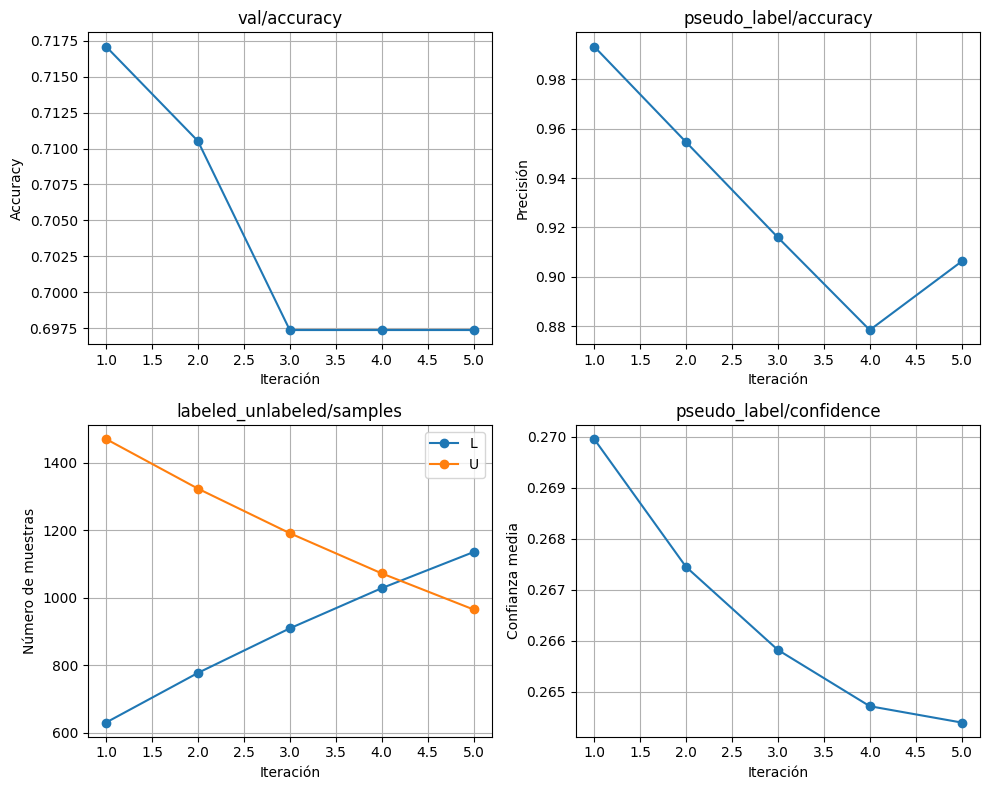

In [15]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# 1. Accuracy en validación
axs[0, 0].plot(history_df["iteration"], history_df["val_accuracy"], marker="o")
axs[0, 0].set_title("val/accuracy")
axs[0, 0].set_xlabel("Iteración")
axs[0, 0].set_ylabel("Accuracy")
axs[0, 0].grid(True)

# 2. Precisión de pseudo-etiquetas
axs[0, 1].plot(history_df["iteration"], history_df["pseudo_label_accuracy"], marker="o")
axs[0, 1].set_title("pseudo_label/accuracy")
axs[0, 1].set_xlabel("Iteración")
axs[0, 1].set_ylabel("Precisión")
axs[0, 1].grid(True)

# 3. Número de muestras etiquetadas
axs[1, 0].plot(history_df["iteration"], history_df["n_labeled"], marker="o", label="L")
axs[1, 0].plot(history_df["iteration"], history_df["n_unlabeled"], marker="o", label="U")
axs[1, 0].set_title("labeled_unlabeled/samples")
axs[1, 0].set_xlabel("Iteración")
axs[1, 0].set_ylabel("Número de muestras")
axs[1, 0].legend()
axs[1, 0].grid(True)

# 4. Confianza media seleccionada
axs[1, 1].plot(history_df["iteration"], history_df["mean_confidence_selected"], marker="o")
axs[1, 1].set_title("pseudo_label/confidence")
axs[1, 1].set_xlabel("Iteración")
axs[1, 1].set_ylabel("Confianza media")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
# Evaluación del AdaBoost supervisado con L

baseline_test_acc, baseline_test_precision, baseline_test_recall, baseline_test_specificity, baseline_accuracy_clase_df, baseline_test_pred, baseline_test_cm = evaluar_modelo(
    baseline_model,
    X_test_features,
    y_test_encoded,
    classes,
    title="AdaBoost supervisado con subconjunto L - Test"
)


AdaBoost supervisado con subconjunto L - Test

Métricas globales:
         Métrica     Valor
0       Accuracy  0.716216
1      Precision  0.723907
2         Recall  0.716216
3  Especificidad  0.905405

Accuracy por clase:
         Clase  Accuracy por clase
0     ala_fija              0.6757
1  helicoptero              0.7568
2   multirotor              0.7838
3       no_uav              0.6486


In [17]:
# Evaluación del AdaBoost semi-supervisado

ssl_test_acc, ssl_test_precision, ssl_test_recall, ssl_test_specificity, ssl_accuracy_clase_df, ssl_test_pred, ssl_test_cm = evaluar_modelo(
    final_ssl_model,
    X_test_features,
    y_test_encoded,
    classes,
    title="AdaBoost semi-supervisado - Test"
)


AdaBoost semi-supervisado - Test

Métricas globales:
         Métrica     Valor
0       Accuracy  0.743243
1      Precision  0.765795
2         Recall  0.743243
3  Especificidad  0.914414

Accuracy por clase:
         Clase  Accuracy por clase
0     ala_fija              0.6757
1  helicoptero              0.8649
2   multirotor              0.7297
3       no_uav              0.7027


In [18]:
# Comparación rápida

print("Comparación en test")
print("-------------------")
print(f"AdaBoost supervisado con L:       {baseline_test_acc:.4f}")
print(f"AdaBoost semi-supervisado SSL:    {ssl_test_acc:.4f}")
print(f"Diferencia:                       {ssl_test_acc - baseline_test_acc:.4f}")

Comparación en test
-------------------
AdaBoost supervisado con L:       0.7162
AdaBoost semi-supervisado SSL:    0.7432
Diferencia:                       0.0270


In [19]:
# Tabla comparativa entre ambos modelos

comparacion_resultados = pd.DataFrame({
    "Modelo": [
        "AdaBoost supervisado con L",
        "AdaBoost semi-supervisado"
    ],
    "Accuracy": [
        baseline_test_acc,
        ssl_test_acc
    ],
    "Precision": [
        baseline_test_precision,
        ssl_test_precision
    ],
    "Recall": [
        baseline_test_recall,
        ssl_test_recall
    ],
    "Especificidad": [
        baseline_test_specificity,
        ssl_test_specificity
    ]
})

comparacion_resultados

,Modelo,Accuracy,Precision,Recall,Especificidad
0,AdaBoost supervisado con L,0.716216,0.723907,0.716216,0.905405
1,AdaBoost semi-supervisado,0.743243,0.765795,0.743243,0.914414


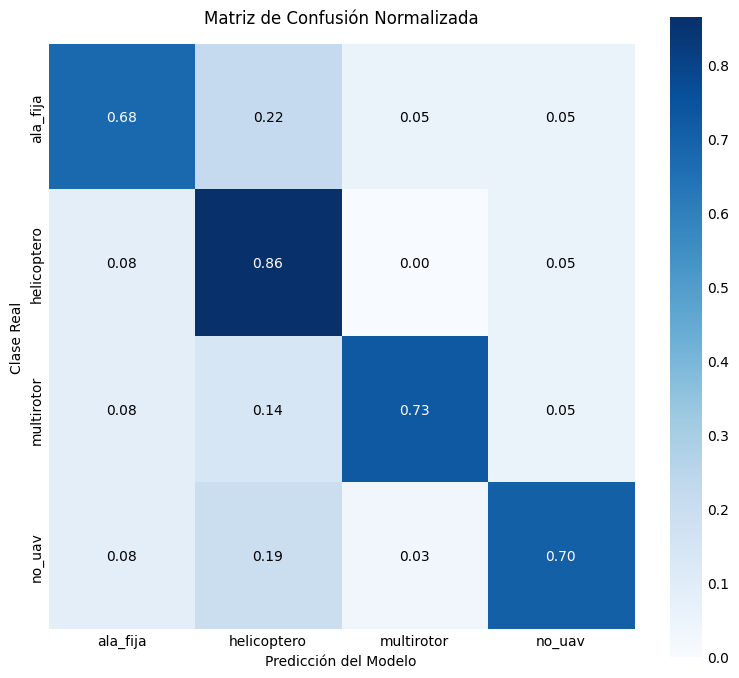

In [25]:
# Dibujar la matriz de confusión

# Predicciones del modelo final
y_pred_ssl = final_ssl_model.predict(X_test_features)

# Matriz de confusión normalizada por filas
cm = confusion_matrix(
    y_test_encoded,
    y_pred_ssl,
    normalize="true"
)

# eje X = predicciones
# eje Y = clases reales
cm_plot = cm

fig, ax = plt.subplots(figsize=(8, 7))

# Dibujar matriz
im = ax.imshow(
    cm_plot,
    interpolation="nearest",
    cmap=plt.cm.Blues
)

# Barra de color
cbar = plt.colorbar(im, ax=ax)

# Quitar borde negro de la barra de color
cbar.outline.set_visible(False)

# Quitar pequeñas marcas de la barra
cbar.ax.tick_params(length=0)

# Quitar bordes extra de la barra
for spine in cbar.ax.spines.values():
    spine.set_visible(False)

# Etiquetas de clases
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))

ax.set_xticklabels(classes, rotation=0, ha="center")
ax.set_yticklabels(classes, rotation=90, va="center")

# Título y nombres de ejes
ax.set_title("Matriz de Confusión Normalizada", pad=15)
ax.set_xlabel("Predicción del Modelo")
ax.set_ylabel("Clase Real")

# Escribir valores dentro de las celdas
for i in range(cm_plot.shape[0]):
    for j in range(cm_plot.shape[1]):
        value = cm_plot[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value > 0.5 else "black"
        )

# Quitar borde negro alrededor de la matriz
for spine in ax.spines.values():
    spine.set_visible(False)

# Quitar marcas pequeñas de los ejes
ax.tick_params(axis="both", which="both", length=0)

plt.tight_layout()

# Guardar imagen en alta resolución
plt.savefig(
    "matriz_confusion_normalizada_adaboost_estilo_companero.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()